## Naomi's Notebook

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np
import scipy.stats as stats

In [2]:
data = pd.read_csv('ai_jobs_market_2025_2026.csv')
data

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,AIJOB1496,Multimodal AI Engineer,AI Engineering,Lead (10+ yrs),8,Master's,262000.0,160000,300000,Toronto,...,8.8,90,23.6,7.5,2026,1,1,1,0,Senior ($200-300k)
1496,AIJOB1497,NLP Engineer,AI Engineering,Senior (6-9 yrs),9,Bootcamp/Self-taught,163000.0,145000,290000,Berlin,...,6.7,91,66.5,7.8,2025,3,1,0,0,Upper-Mid ($150-200k)
1497,AIJOB1498,AI Compliance Manager,Governance,Mid (3-5 yrs),10,Master's,127000.0,100000,200000,Zurich,...,10.9,68,15.3,8.3,2026,3,0,1,0,Mid ($100-150k)
1498,AIJOB1499,NLP Engineer,AI Engineering,Lead (10+ yrs),4,Bachelor's,145000.0,145000,290000,Bangalore,...,8.5,91,78.8,7.4,2025,5,1,1,0,Mid ($100-150k)


See if the annual salary is skewed

<Axes: xlabel='annual_salary_usd', ylabel='Count'>

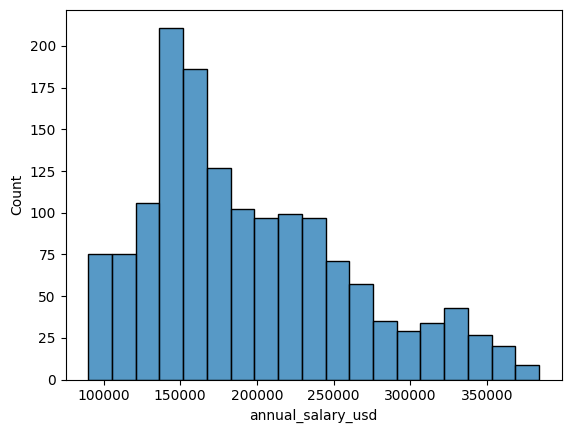

In [3]:
sns.histplot(data, x = 'annual_salary_usd')

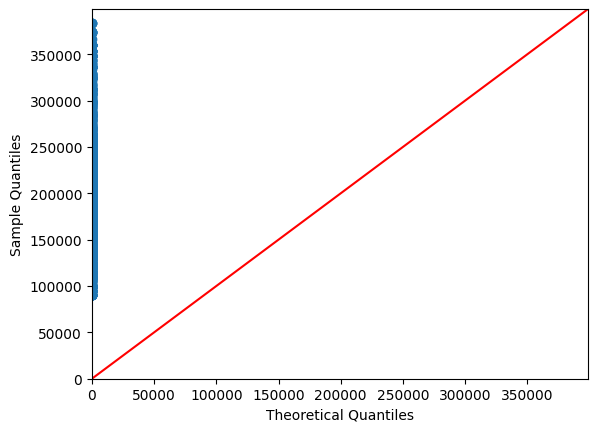

In [4]:
sm.qqplot(data['annual_salary_usd'], line = '45')
plt.show()


Since annual salary is skewed, we will use the log of annual salary.

In [5]:
data['log_salary'] = np.log(data['annual_salary_usd'])
data.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier,log_salary
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k),12.384219
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k),12.019743
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k),12.793859
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k),11.989160
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k),12.553202


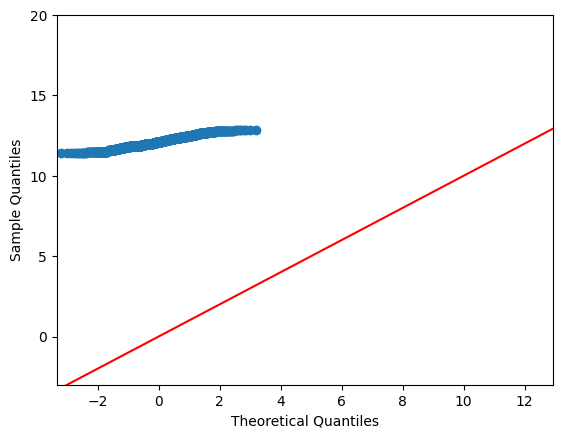

In [6]:
sm.qqplot(data['log_salary'], line = '45')
plt.ylim((-3,20))
plt.show()

In [13]:
print('Optimal lambda value from boxcox transformation:',stats.boxcox(data['annual_salary_usd'])[1])

Optimal lambda value from boxcox transformation: -0.12519558128627847


Questions to answer

1. Does years of experience have an effect on salary? Does increasing years of experience have the same effect across company size? Across industry? Across city?

## Linear Regression Model

We will use multivariate linear regression to see which variables have an effect on salary.  

### Variable selection

We want to select the variables that are relevant for predicting annual salary. We will use both forward and backward selection to assess the resulting variables.


In [7]:
def add(df, selected_columns, columns, criterion, response='y'):
    best_criterion = np.inf
    best_column = None
    for column in columns - selected_columns:
        new_columns = selected_columns.union({column})
        formula = f'{response} ~ {" + ".join(new_columns)}'
        current_criterion = criterion(formula, df)
        if current_criterion < best_criterion:
            best_criterion = current_criterion
            best_column = column
    return selected_columns.union({best_column}), best_criterion

In [8]:
def forward(df, criterion, response='y'):
    selected_columns = set()
    columns = set(df.columns.drop(response))
    best_criterion = np.inf
    while len(selected_columns) < len(columns):
        potential_columns, current_criterion = add(df, selected_columns, columns, criterion, response)
        if current_criterion > best_criterion:
            break
        else:
            selected_columns = potential_columns
            best_criterion = current_criterion
            print(f'Criterion: {best_criterion}')
    return selected_columns

In [9]:
bic_criterion = lambda formula, df: smf.ols(formula, data=df).fit().bic

In [14]:
f_vars = forward(data, bic_criterion, response = 'log_salary')
print(f_vars)

Criterion: -77168.95190516626


KeyboardInterrupt: 

Backward selection

In [ ]:
def remove(df, selected_columns, criterion, response='y'):
    ...
    return worst_column, worst_criterion

In [ ]:
def backward(df, criterion, response='y'):
    ...
    return selected_columns

In [ ]:


#backward
b_vars = backward(df, bic_criterion, response = 'medv')